## 6. Data Splitting

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [30]:
import pandas as pd
import numpy as np
import math
import re
import string
import matplotlib.pyplot as plt
from tqdm import tqdm
from langdetect import detect_langs, LangDetectException
import nltk # Added this line
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

nltk.download("punkt")
nltk.download("stopwords")
nltk.download('punkt_tab')


from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\haida\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\haida\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\haida\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [59]:
from pathlib import Path
ROOT = Path.cwd().parent
DATA_PATH = ROOT / "dataset_raw" / "monster_hunter_wilds_reviews.csv"

df_sentiment = pd.read_csv(DATA_PATH)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [60]:
# menampilkan 5 data teratas
df_sentiment.head(5)

,recommendationid,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,playtime_forever,playtime_last_two_weeks,playtime_at_review,timestamp_created,timestamp_updated
0,229483664,Literally Unplayable \n\nI heard that this gam...,False,1,0,0.500713,0,True,False,False,104,104,104,1783067470,1783067470
1,229483288,+1,True,0,0,0.500000,0,False,False,False,16501,0,16501,1783067009,1783067009
2,229482413,14hrs to complete Low Rank story (Credits roll...,True,2,0,0.545455,0,False,False,False,5158,2103,5158,1783065878,1783065878
3,229482364,Buy it with 50-60%,True,0,0,0.500000,0,True,False,False,2844,2844,2569,1783065820,1783065820
4,229480976,"Really fun and cool graphics, but I am so bad ...",True,0,0,0.500000,0,False,False,False,83,83,83,1783064109,1783064109


In [61]:
# Tinjau jumlah baris kolom dan jenis data
df_sentiment.info

<bound method DataFrame.info of       recommendationid                                             review  \
0            229483664  Literally Unplayable \n\nI heard that this gam...   
1            229483288                                                 +1   
2            229482413  14hrs to complete Low Rank story (Credits roll...   
3            229482364                                 Buy it with 50-60%   
4            229480976  Really fun and cool graphics, but I am so bad ...   
...                ...                                                ...   
4995         219409354  Do not buy Monster Hunter wilds unless you hav...   
4996         219409306                                   crashes too much   
4997         219407840  I can't recommend this.\nI dumped about 60 hou...   
4998         219407010  Runs like ♥♥♥♥. Need the worlds best pc to run...   
4999         219401339  The 'mixed' rating is undeserved (slight bias)...   

      voted_up  votes_up  votes_funny  weig

In [62]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df_sentiment.describe()

,recommendationid,votes_up,votes_funny,weighted_vote_score,comment_count,playtime_forever,playtime_last_two_weeks,playtime_at_review,timestamp_created,timestamp_updated
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03
mean,2.244450e+08,2.106200,0.414800,0.501355,0.139200,8931.516600,489.059600,7048.609000,1.777585e+09,1.777658e+09
std,3.271146e+06,21.728298,3.140559,0.029639,1.227895,12587.193385,1126.526787,11134.373281,3.574431e+06,3.570998e+06
min,2.194013e+08,0.000000,0.000000,0.285642,0.000000,8.000000,0.000000,8.000000,1.772246e+09,1.772246e+09
25%,2.213275e+08,0.000000,0.000000,0.500000,0.000000,2261.500000,0.000000,1090.750000,1.774136e+09,1.774219e+09
50%,2.241741e+08,0.000000,0.000000,0.500000,0.000000,5260.000000,0.000000,3367.000000,1.777238e+09,1.777397e+09
75%,2.276902e+08,1.000000,0.000000,0.500000,0.000000,10936.500000,363.500000,8597.500000,1.781150e+09,1.781201e+09
max,2.294837e+08,662.000000,164.000000,0.893124,39.000000,189554.000000,14941.000000,181847.000000,1.783067e+09,1.783071e+09


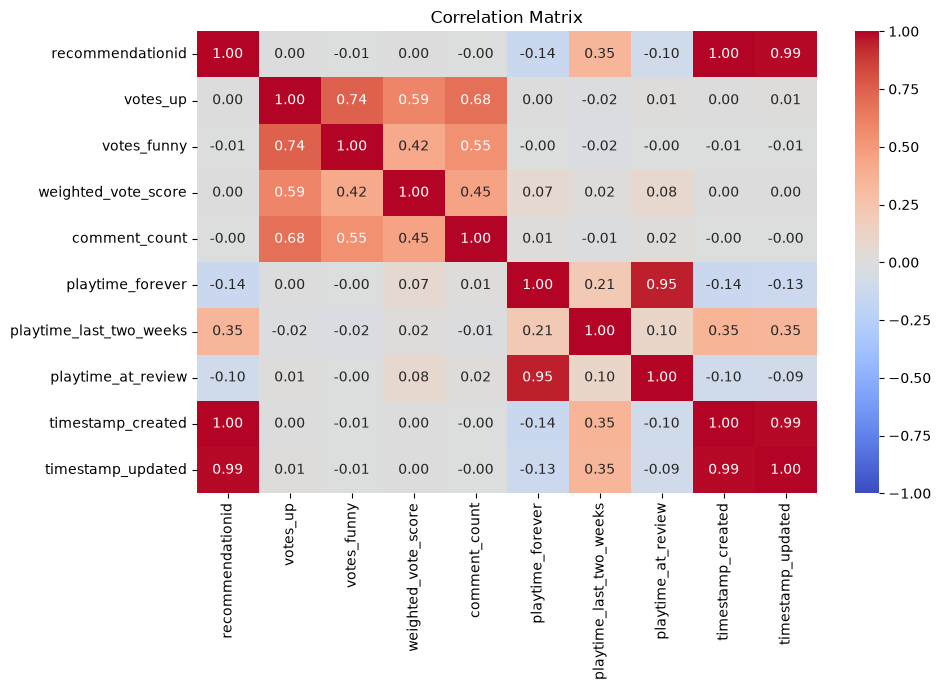

In [63]:
# Menampilkan korelasi antar fitur

# Memilih kolom numerik
numerical_cols = df_sentiment.select_dtypes(include=['number']).columns

# Hitung matriks korelasi
correlation = df_sentiment[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

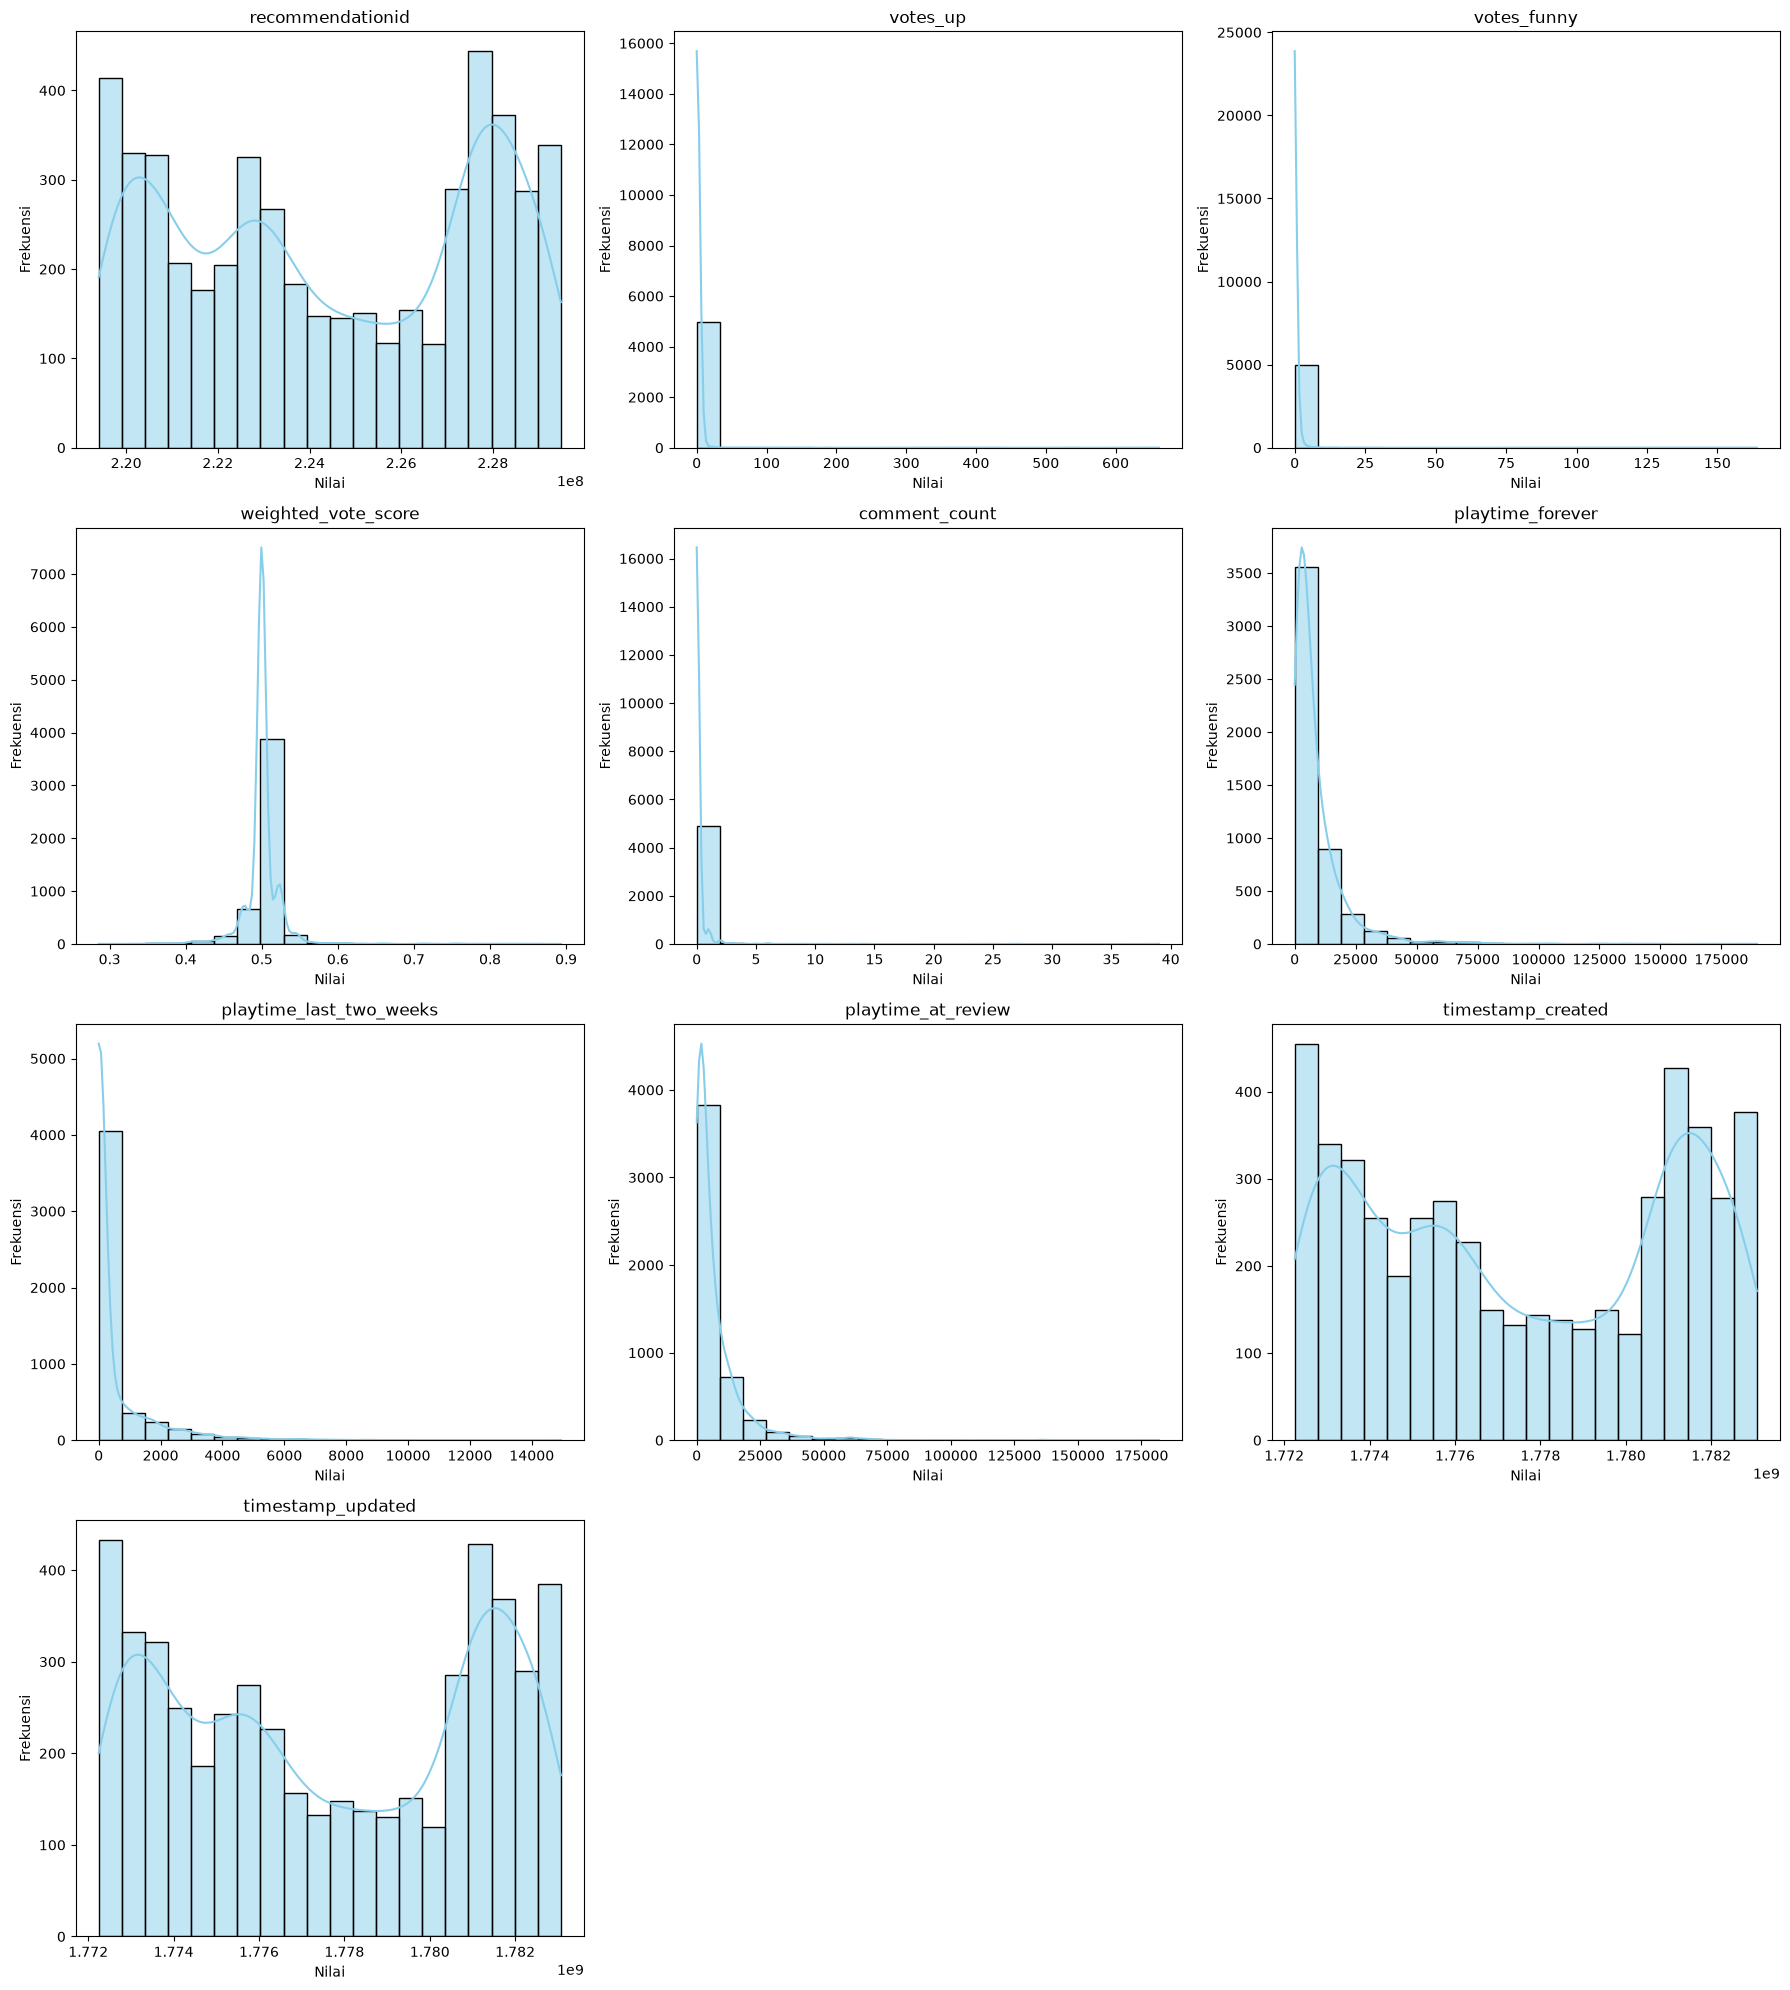

In [65]:
# Menampilkan histogram untuk semua kolom numerik

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):
    sns.histplot(
        df_sentiment[column],
        bins=20,
        kde=True,
        color='skyblue',
        ax=axes[i]
    )

    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

# Menghapus subplot yang tidak terpakai
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [32]:
# Mengecek dataset menggunakan isnull().sum()
df_sentiment.isnull().sum()


recommendationid                0
review                         22
voted_up                        0
votes_up                        0
votes_funny                     0
weighted_vote_score             0
comment_count                   0
steam_purchase                  0
received_for_free               0
written_during_early_access     0
playtime_forever                0
playtime_last_two_weeks         0
playtime_at_review              0
timestamp_created               0
timestamp_updated               0
dtype: int64

In [33]:
df_sentiment.duplicated().sum()

np.int64(0)

In [34]:
# Menangani data yang hilang

# Panggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df_sentiment.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df_sentiment.isnull().sum()


recommendationid               0
review                         0
voted_up                       0
votes_up                       0
votes_funny                    0
weighted_vote_score            0
comment_count                  0
steam_purchase                 0
received_for_free              0
written_during_early_access    0
playtime_forever               0
playtime_last_two_weeks        0
playtime_at_review             0
timestamp_created              0
timestamp_updated              0
dtype: int64

In [35]:
# Menghapus data duplikat.

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df_sentiment.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df_sentiment.duplicated().sum()

np.int64(0)

In [69]:
# Melakukan drop 

cols_to_drop = [
    col for col in df_sentiment.columns
    if 'votes_up' in col.lower()
    or 'votes_funny' in col.lower()
    or 'weighted_vote_score' in col.lower()
    or 'comment_count' in col.lower()
    or 'steam_purchase' in col.lower()
    or 'received_for_free' in col.lower()
    or 'written_during_early_access' in col.lower()
    or 'playtime_forever' in col.lower()
    or 'playtime_last_two_weeks' in col.lower()
    or 'playtime_at_review' in col.lower()
    or 'timestamp_created' in col.lower()
    or 'timestamp_updated' in col.lower()
]

df_sentiment = df_sentiment.drop(columns=cols_to_drop)

df_sentiment.head()

,recommendationid,review,voted_up
0,229483664,Literally Unplayable \n\nI heard that this gam...,False
1,229483288,+1,True
2,229482413,14hrs to complete Low Rank story (Credits roll...,True
3,229482364,Buy it with 50-60%,True
4,229480976,"Really fun and cool graphics, but I am so bad ...",True


In [70]:
# CaseFolding
df_sentiment["review"] = df_sentiment["review"].str.lower()

# Menghapus url
def remove_url(text):
    return re.sub(r"http\S+|www\S+", "", text)
df_sentiment["review"] = df_sentiment["review"].fillna("").apply(remove_url)

# menghapus HTML
def remove_html(text):
    return re.sub(r"<.*?>", "", text)
df_sentiment["review"] = df_sentiment["review"].apply(remove_html)

# Menghapus mention @
def remove_mention(text):
    return re.sub(r"@\S+", "", text)
df_sentiment["review"] = df_sentiment["review"].apply(remove_mention)

# menghapus emoji
EMOJI_MAP = {
    "❤️": " love ", "❤": " love ", "💕": " love ", "💖": " love ", "💗": " love ", "😍": " love ", "🥰": " love ",
    "😊": " happy ", "😄": " happy ", "😁": " happy ", ":) ": " happy ", "🙂": " happy ",
    "😂": " laugh ", "🤣": " laugh ",
    "😭": " crying ", "😢": " sad ", "☹️": " sad ", "🙁": " sad ",
    "😡": " angry ", "🤬": " angry ", "😠": " angry ",
    "👍": " good ", "👎": " bad ",
    "🔥": " awesome ", "💯": " perfect ", "💩": " poop "
}

def clean_text(text):
    if not isinstance(text, str):
        return text
    for emo, word in EMOJI_MAP.items():
        text = text.replace(emo, word)
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"\s+", " ", text).strip()
    return text
df_sentiment["review"] = df_sentiment["review"].apply(clean_text)

In [71]:
from traitlets import Instance
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.

encoders = {}

label_encoder = LabelEncoder()

df_sentiment["voted_up"] = label_encoder.fit_transform(df_sentiment["voted_up"])

df_sentiment.head(5)


,recommendationid,review,voted_up
0,229483664,literally unplayable i heard that this game ha...,0
1,229483288,+1,1
2,229482413,14hrs to complete low rank story (credits roll...,1
3,229482364,buy it with 50-60%,1
4,229480976,"really fun and cool graphics, but i am so bad ...",1


In [80]:
from ast import Constant

df_sentiment.columns.tolist()


['recommendationid', 'review', 'voted_up', 'tokens', 'clean_review', 'label']

In [73]:
display(df_sentiment.head())

,recommendationid,review,voted_up
0,229483664,literally unplayable i heard that this game ha...,0
1,229483288,+1,1
2,229482413,14hrs to complete low rank story (credits roll...,1
3,229482364,buy it with 50-60%,1
4,229480976,"really fun and cool graphics, but i am so bad ...",1


In [74]:
# Menghapus Punctuation
def remove_punctuation(text):
    if not isinstance(text, str):
        return text
    return text.translate(str.maketrans("", "", string.punctuation))
df_sentiment["review"] = df_sentiment["review"].apply(remove_punctuation)

# Menghapus extra whitespace
def remove_whitespace(text):
    if not isinstance(text, str):
        return text
    return re.sub(r"\s+", " ", text).strip()
df_sentiment["review"] = df_sentiment["review"].apply(remove_whitespace)

# Tokenization
df_sentiment["tokens"] = df_sentiment["review"].apply(word_tokenize)

# Stopword
stop_words = set(stopwords.words("english"))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]
df_sentiment["tokens"] = df_sentiment["tokens"].apply(remove_stopwords)

# Lemmatization
nltk.download('wordnet') # Download wordnet resource
lemmatizer = WordNetLemmatizer()
df_sentiment["tokens"] = df_sentiment["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

# Penggabungan
df_sentiment["clean_review"] = df_sentiment["tokens"].apply(lambda x: " ".join(x))

# Display the DataFrame with clean_review
display(df_sentiment.head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\haida\AppData\Roaming\nltk_data...


,recommendationid,review,voted_up,tokens,clean_review
0,229483664,literally unplayable i heard that this game ha...,0,"[literally, unplayable, heard, game, pc, port,...",literally unplayable heard game pc port perfor...
1,229483288,1,1,[1],1
2,229482413,14hrs to complete low rank story credits roll ...,1,"[14hrs, complete, low, rank, story, credit, ro...",14hrs complete low rank story credit roll 86 h...
3,229482364,buy it with 5060,1,"[buy, 5060]",buy 5060
4,229480976,really fun and cool graphics but i am so bad i...,1,"[really, fun, cool, graphic, bad, killing, roc...",really fun cool graphic bad killing rock wall ...


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False,
    strip_accents="unicode"
)

X = tfidf_vectorizer.fit_transform(df_sentiment["clean_review"].fillna(""))

In [76]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def label(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.2:
        return "Positive"

    elif score <= -0.2:
        return "Negative"


df_sentiment["label"] = df_sentiment["clean_review"].apply(label)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\haida\AppData\Roaming\nltk_data...


In [83]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get the target labels
y = df_sentiment['label']

# Remove rows with None labels (neutral sentiment)
mask = y.notna()
indices = np.where(mask)[0]
X_filtered = X[indices]
y_filtered = y[mask].reset_index(drop=True)

print(f"Total samples: {len(y)}")
print(f"Samples with label: {len(y_filtered)}")
print(f"Samples removed (neutral): {len(y) - len(y_filtered)}")

# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_filtered
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Total samples: 5000
Samples with label: 3795
Samples removed (neutral): 1205

Training set size: 3036
Test set size: 759

Training set class distribution:
label
Positive    2476
Negative     560
Name: count, dtype: int64

Test set class distribution:
label
Positive    619
Negative    140
Name: count, dtype: int64


In [84]:
# Further split training data into train (80%) and validation (20%)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Data Split Summary:")
print("=" * 50)
print(f"Training set size: {X_train_split.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Total labeled samples: {X_train_split.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train_split.value_counts()}")
print(f"\nValidation set class distribution:\n{y_val.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Data Split Summary:
Training set size: 2428 samples
Validation set size: 608 samples
Test set size: 759 samples
Total labeled samples: 3795

Training set class distribution:
label
Positive    1980
Negative     448
Name: count, dtype: int64

Validation set class distribution:
label
Positive    496
Negative    112
Name: count, dtype: int64

Test set class distribution:
label
Positive    619
Negative    140
Name: count, dtype: int64


In [85]:
from imblearn.under_sampling import RandomUnderSampler

# Apply RandomUnderSampler to balance the training set
# This will randomly undersample the majority class (Positive) to match minority class (Negative)
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Convert sparse matrix to dense format for undersampler
X_train_dense = X_train_split.toarray()
X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train_dense, y_train_split)

# Convert back to sparse matrix for memory efficiency
from scipy.sparse import csr_matrix
X_train_balanced = csr_matrix(X_train_balanced)

print("After RandomUnderSampler:")
print("=" * 50)
print(f"Training set size: {X_train_balanced.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nBalanced training set class distribution:")
print(y_train_balanced.value_counts())
print(f"\nClass balance ratio: {y_train_balanced.value_counts()['Negative'] / y_train_balanced.value_counts()['Positive']:.2%}")

After RandomUnderSampler:
Training set size: 896 samples
Validation set size: 608 samples
Test set size: 759 samples

Balanced training set class distribution:
label
Negative    448
Positive    448
Name: count, dtype: int64

Class balance ratio: 100.00%


In [88]:
## Export Cleaned Data to CSV

# Define output path
output_path = ROOT / ".." / "SMSL_REYHAN-HAIDAR" / "data_clean.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataframe to CSV
df_sentiment.to_csv(output_path, index=False, encoding='utf-8')

print(f"✓ Cleaned data exported to: {output_path}")
print(f"✓ Total rows: {len(df_sentiment)}")
print(f"✓ Total columns: {len(df_sentiment.columns)}")
print(f"\nColumns saved: {df_sentiment.columns.tolist()}")

✓ Cleaned data exported to: d:\porto\project\SMSL_Reyhan-Haidar\..\SMSL_REYHAN-HAIDAR\data_clean.csv
✓ Total rows: 5000
✓ Total columns: 6

Columns saved: ['recommendationid', 'review', 'voted_up', 'tokens', 'clean_review', 'label']
